In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv


c:\Users\harsh\PROJECTS\LangGraph\agentic\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()

True

In [4]:
model=ChatOpenAI()

In [3]:
class BlogState(TypedDict):
    topic:str
    outline:str
    final_article:str

In [6]:
def outline_creator(state:BlogState)->BlogState:
    topic=state['topic']
    prompt=f'geenrate the ouline for the {topic}'
    outline=model.invoke(prompt)
    state['outline']=outline
    return state

In [7]:
def blog_generator(state:BlogState)->BlogState:
    outline=state['outline']
    prompt=f'generate a blog on the basis of this {outline}'
    final_article=model.invoke(prompt)
    state['final_article']=final_article
    return state

In [10]:
graph=StateGraph(BlogState)
graph.add_node('create_outline',outline_creator)
graph.add_node('generating_blog',blog_generator)
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','generating_blog')
graph.add_edge('generating_blog',END)
workflow=graph.compile()


In [12]:
initial_state={'topic':'machine learning'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'topic': 'machine learning', 'outline': AIMessage(content='I. Introduction \n   A. Background information on machine learning \n   B. Definition of machine learning \n   C. Importance of machine learning in various industries \n\nII. Types of machine learning \n   A. Supervised learning \n   B. Unsupervised learning \n   C. Reinforcement learning \n\nIII. Machine learning algorithms \n   A. Decision trees \n   B. Support vector machines \n   C. Neural networks \n   D. Random forests \n\nIV. Applications of machine learning \n   A. Healthcare \n   B. Finance \n   C. Marketing \n   D. Transportation \n\nV. Challenges in machine learning \n   A. Data quality and quantity \n   B. Model interpretability \n   C. Ethical considerations \n\nVI. Future trends in machine learning \n   A. Advancements in deep learning \n   B. Integration of machine learning with other technologies \n   C. Impact of automation and AI \n\nVII. Conclusion \n   A. Summary of key points \n   B. Importance of continue

In [ ]:
print(final_state['outline'])

content='I. Introduction \n   A. Background information on machine learning \n   B. Definition of machine learning \n   C. Importance of machine learning in various industries \n\nII. Types of machine learning \n   A. Supervised learning \n   B. Unsupervised learning \n   C. Reinforcement learning \n\nIII. Machine learning algorithms \n   A. Decision trees \n   B. Support vector machines \n   C. Neural networks \n   D. Random forests \n\nIV. Applications of machine learning \n   A. Healthcare \n   B. Finance \n   C. Marketing \n   D. Transportation \n\nV. Challenges in machine learning \n   A. Data quality and quantity \n   B. Model interpretability \n   C. Ethical considerations \n\nVI. Future trends in machine learning \n   A. Advancements in deep learning \n   B. Integration of machine learning with other technologies \n   C. Impact of automation and AI \n\nVII. Conclusion \n   A. Summary of key points \n   B. Importance of continued research and development in machine learning \n  

: 

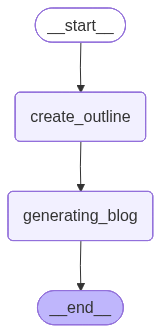

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())